In [1]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, Flatten, Input, Activation
from tensorflow.keras.layers import Reshape, Conv2DTranspose
from tensorflow.keras.models import Model
from tensorflow.keras import backend as K

In [2]:
import numpy as np
from pathlib import Path

In [3]:
import sys
sys.path.append("..")
from dataset import make_sr_dataset
import matplotlib.pyplot as plt

2.18.1


In [4]:
print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.18.1
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
print("GPUs:", gpus)

if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("Metal GPU je spreman.")
else:
    print("TensorFlow i dalje radi samo na CPU.")

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Metal GPU je spreman.


In [6]:
#pravljenje semeta za reproduktabilnost
np.random.seed(7)

In [15]:
#Globalne promenljive
HR_SIZE = 128
SCALE = 2
LR_SIZE = 64
BATCH = 32
EPOCHS = 100

In [16]:
#Pravljenje liste tipa string od svih podataka
ROOT = Path("../data/raw/Flickr2K")
path = [str(p) for p in ROOT.glob('*.png')]

In [17]:
print(path[:5])

['../data/raw/Flickr2K/001927.png', '../data/raw/Flickr2K/001099.png', '../data/raw/Flickr2K/000387.png', '../data/raw/Flickr2K/002590.png', '../data/raw/Flickr2K/002584.png']


In [18]:
#Nasumično mešanje fajlova
np.random.shuffle(path)

In [19]:
#Podela na train test, val u odnosu 80% 10% 10%
train_paths = path[:2120]
val_paths = path[2120:2120+265]
test_paths = path[2120+265 :]

In [20]:
print(len(train_paths))
print(len(val_paths))
print(len(test_paths))

2120
265
265


In [21]:
#Pravljenje tenzora putem dataset.py fajla za train i val
ds_train = make_sr_dataset(train_paths,HR_SIZE,SCALE,BATCH,True)
ds_val = make_sr_dataset(val_paths,HR_SIZE,SCALE,BATCH,False)

In [22]:
#definisanje ulaznih parametara za encoder
input_shape = (64,64,3)
kernel_size = 3
layer_filters = [32, 64,128]

In [23]:
#Konstrukcija enkodera
# 3 conv sloja, prvi i drugi uče i izvlače parametre dok treći smanjjue sliku za pola
inputs = Input(shape = input_shape,name= 'encoder_input')
x = inputs

for filters in layer_filters:
    x = Conv2D(filters = filters,kernel_size = kernel_size,strides = 1,activation = 'relu',padding = 'same')(x)
    x = Conv2D(filters = filters,kernel_size = kernel_size,strides = 1,activation = 'relu',padding = 'same')(x)
    x = Conv2D(filters = filters,kernel_size = kernel_size,strides = 2,activation = 'relu',padding = 'same')(x)


shape = K.int_shape(x)

encoder = Model(inputs,x,name = 'encoder')
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 480,768 (1.83 MB)

 Trainable params: 480,768 (1.83 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
#Konstrukcija dekodera
#Prima izlaz enkodera,
#Ima 4 sloja za po svaki layer, prvi povećava sliku(upsampling) za duplu vrednost,
# drugi i treći rekonstruišu detalje na slici
#četvrti je uveličavanje na željenu veličinu tj cilj projekta super resolution
#Kao aktivacionu funkciju koristimo sigmoidnu af
decoder_input = Input(shape=(8,8,128))
x = decoder_input
for filters in layer_filters[::-1]:
    x = Conv2DTranspose(filters = filters,kernel_size = kernel_size,strides = 2,activation = 'relu',padding = 'same')(x)
    x = Conv2D(filters = filters,kernel_size = kernel_size,strides = 1,activation = 'relu',padding = 'same')(x)
    x = Conv2D(filters = filters,kernel_size = kernel_size,strides = 1,activation = 'relu',padding = 'same')(x)

x = Conv2DTranspose(filters = 3,kernel_size = kernel_size, strides = 2,padding= 'same')(x)
#x = Conv2D(filters = filters,kernel_size = kernel_size,strides = 1,activation = 'relu',padding = 'same')(x)

outputs = Activation('sigmoid',name = 'decoder_output')(x)
decoder = Model(inputs = decoder_input, outputs = outputs, name = 'decoder')

decoder.summary(line_length = 110)

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                   ┃ Output Shape                        ┃             Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)                       │ (None, 8, 8, 128)                   │                   0 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ conv2d_transpose (Conv2DTranspose)             │ (None, 16, 16, 128)                 │             147,584 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ conv2d_9 (Conv2D)                              │ (None, 16, 16, 128)                 │             147,584 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ conv2d_10 (Conv2D)                             │ (None, 16, 16, 128)                 │             147,584 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ conv2d_transpose_1 (Conv2DTranspose)           │ (None, 32, 32, 64)                  │              73,792 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ conv2d_11 (Conv2D)                             │ (None, 32, 32, 64)                  │              36,928 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ conv2d_12 (Conv2D)                             │ (None, 32, 32, 64)                  │              36,928 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ conv2d_transpose_2 (Conv2DTranspose)           │ (None, 64, 64, 32)                  │              18,464 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ conv2d_13 (Conv2D)                             │ (None, 64, 64, 32)                  │               9,248 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ conv2d_14 (Conv2D)                             │ (None, 64, 64, 32)                  │               9,248 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ conv2d_transpose_3 (Conv2DTranspose)           │ (None, 128, 128, 3)                 │                 867 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ decoder_output (Activation)                    │ (None, 128, 128, 3)                 │                   0 │
└────────────────────────────────────────────────┴─────────────────────────────────────┴─────────────────────┘

 Total params: 628,227 (2.40 MB)

 Trainable params: 628,227 (2.40 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
#kreiranje glvnog autoencoder modela koji sadrži encoder i decoder
autoencoder = Model(inputs,decoder(encoder(inputs)),name = 'autoencoder')
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 8, 8, 128)      │       480,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 128, 128, 3)    │       628,227 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,108,995 (4.23 MB)

 Trainable params: 1,108,995 (4.23 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
#Definisanje funkcije za PSNR (Peak signal to noise ratio) koja ocenjuje kvalitet rekonstuisane slike u odnosu na original
def psnr_metrics(y_true,y_pred):
    return tf.image.psnr(y_true,y_pred,max_val = 1.0)

In [27]:
Path("../models").mkdir(parents=True, exist_ok=True)

In [28]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath="../models/best_model.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

In [29]:
#Kompajliranje i treniranje modela, čuvanje modela
autoencoder.compile(loss='MAE', metrics = [psnr_metrics],optimizer='adam')

In [30]:
history = autoencoder.fit(
    ds_train,
    validation_data=ds_val,
    epochs=EPOCHS,
    verbose=1,
    callbacks = callbacks
)

Epoch 1/100


2026-03-11 11:31:08.520672: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


66/66 ━━━━━━━━━━━━━━━━━━━━ 23s 243ms/step - loss: 0.1873 - psnr_metrics: 13.9853 - val_loss: 0.1665 - val_psnr_metrics: 14.2287
Epoch 2/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 16s 238ms/step - loss: 0.1213 - psnr_metrics: 17.1415 - val_loss: 0.1026 - val_psnr_metrics: 18.3110
Epoch 3/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 16s 246ms/step - loss: 0.0998 - psnr_metrics: 18.7512 - val_loss: 0.0974 - val_psnr_metrics: 18.7419
Epoch 4/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 17s 261ms/step - loss: 0.0938 - psnr_metrics: 19.3060 - val_loss: 0.0879 - val_psnr_metrics: 19.9133
Epoch 5/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 17s 258ms/step - loss: 0.0913 - psnr_metrics: 19.5258 - val_loss: 0.0885 - val_psnr_metrics: 19.5279
Epoch 6/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 17s 254ms/step - loss: 0.0850 - psnr_metrics: 20.2921 - val_loss: 0.0858 - val_psnr_metrics: 19.9550
Epoch 7/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 16s 244ms/step - loss: 0.0894 - psnr_metrics: 19.7615 - val_loss: 0.0853 - val_psnr_metrics: 20.2799
Epoch 8/100
66/66 ━━━━━━━━━━━━━━

In [31]:
autoencoder.save("../models/sr_autoencoder.keras")

print("Model saved.")

Model saved.


In [32]:
print(history.history.keys())

dict_keys(['loss', 'psnr_metrics', 'val_loss', 'val_psnr_metrics'])


In [33]:
#Vizuelni prikaz

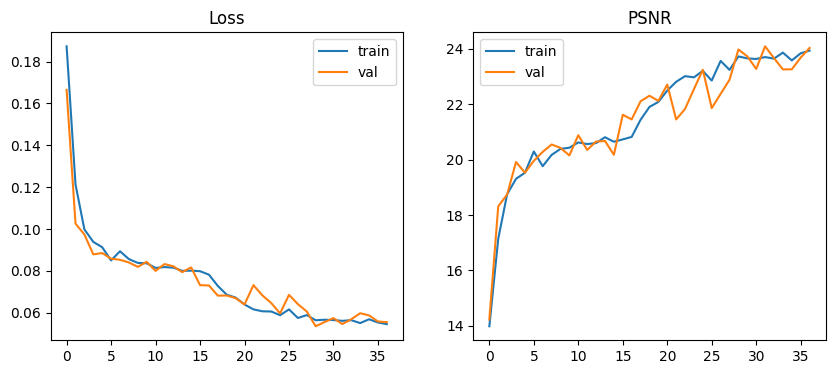

In [34]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['psnr_metrics'], label='train')
plt.plot(history.history['val_psnr_metrics'], label='val')
plt.title("PSNR")
plt.legend()

plt.show()

In [32]:
#Path("../models").mkdir(parents=True, exist_ok=True)

#autoencoder.save("../models/sr_autoencoder.keras")

#print("Model saved.")

In [20]:
#Kreiranje skupa podataka za testiranje

In [35]:
ds_test = make_sr_dataset(test_paths,HR_SIZE,SCALE,BATCH,False)
lr,hr = next(iter(ds_test))

In [36]:
#Predikcija modela

In [37]:
pred = autoencoder.predict(lr)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step


In [38]:
print(pred.shape)

(32, 128, 128, 3)


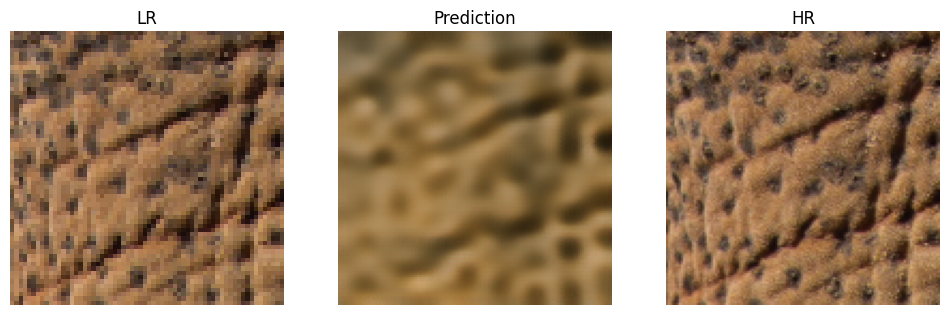

In [39]:
plt.figure(figsize = (12,4))
plt.subplot(1,3,1)
plt.title('LR')
plt.imshow(lr[0])
plt.axis('off')

plt.subplot(1,3,2)
plt.title('Prediction')
plt.imshow(pred[0])
plt.axis('off')

plt.subplot(1,3,3)
plt.title('HR')
plt.imshow(hr[0])
plt.axis('off')

plt.show()

In [40]:
#Konstrukcija enkodera
# 3 conv sloja, prvi i drugi uče i izvlače parametre dok treći smanjjue sliku za pola
inputs = Input(shape = input_shape,name= 'encoder_input')
x = inputs

for filters in layer_filters:
    x = Conv2D(filters = filters,kernel_size = kernel_size,strides = 1,activation = 'relu',padding = 'same')(x)
    x = Conv2D(filters = filters,kernel_size = kernel_size,strides = 2,activation = 'relu',padding = 'same')(x)


shape = K.int_shape(x)

encoder = Model(inputs,x,name = 'smaller_encoder')
encoder.summary()

Model: "smaller_encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 287,008 (1.09 MB)

 Trainable params: 287,008 (1.09 MB)

 Non-trainable params: 0 (0.00 B)

In [41]:
decoder_input = Input(shape=shape[1:])
x = decoder_input
for filters in layer_filters[::-1]:
    x = Conv2DTranspose(filters = filters,kernel_size = kernel_size,strides = 2,activation = 'relu',padding = 'same')(x)
    x = Conv2D(filters = filters,kernel_size = kernel_size,strides = 1,activation = 'relu',padding = 'same')(x)

x = Conv2DTranspose(filters = 3,kernel_size = kernel_size, strides = 2,padding= 'same')(x)
#x = Conv2D(filters = filters,kernel_size = kernel_size,strides = 1,activation = 'relu',padding = 'same')(x)

outputs = Activation('sigmoid',name = 'decoder_output')(x)
decoder = Model(inputs = decoder_input, outputs = outputs, name = 'smaller_decoder')

decoder.summary(line_length = 110)

Model: "smaller_decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                   ┃ Output Shape                        ┃             Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)                     │ (None, 8, 8, 128)                   │                   0 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ conv2d_transpose_4 (Conv2DTranspose)           │ (None, 16, 16, 128)                 │             147,584 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ conv2d_21 (Conv2D)                             │ (None, 16, 16, 128)                 │             147,584 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ conv2d_transpose_5 (Conv2DTranspose)           │ (None, 32, 32, 64)                  │              73,792 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ conv2d_22 (Conv2D)                             │ (None, 32, 32, 64)                  │              36,928 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ conv2d_transpose_6 (Conv2DTranspose)           │ (None, 64, 64, 32)                  │              18,464 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ conv2d_23 (Conv2D)                             │ (None, 64, 64, 32)                  │               9,248 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ conv2d_transpose_7 (Conv2DTranspose)           │ (None, 128, 128, 3)                 │                 867 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ decoder_output (Activation)                    │ (None, 128, 128, 3)                 │                   0 │
└────────────────────────────────────────────────┴─────────────────────────────────────┴─────────────────────┘

 Total params: 434,467 (1.66 MB)

 Trainable params: 434,467 (1.66 MB)

 Non-trainable params: 0 (0.00 B)

In [42]:
#kreiranje glvnog autoencoder modela koji sadrži encoder i decoder
autoencoder = Model(inputs,decoder(encoder(inputs)),name = 'smaller_autoencoder')
autoencoder.summary()

Model: "smaller_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ smaller_encoder (Functional)    │ (None, 8, 8, 128)      │       287,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ smaller_decoder (Functional)    │ (None, 128, 128, 3)    │       434,467 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 721,475 (2.75 MB)

 Trainable params: 721,475 (2.75 MB)

 Non-trainable params: 0 (0.00 B)

In [43]:
callbacks2 = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath="../models/best_model_smaller.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

In [44]:
#Kompajliranje i treniranje modela, čuvanje modela
autoencoder.compile(loss='MAE', metrics = [psnr_metrics],optimizer='adam')

In [45]:
history = autoencoder.fit(
    ds_train,
    validation_data=ds_val,
    epochs=EPOCHS,
    verbose=1,
    callbacks = callbacks2
)

Epoch 1/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 17s 220ms/step - loss: 0.1717 - psnr_metrics: 14.5599 - val_loss: 0.1205 - val_psnr_metrics: 16.7830
Epoch 2/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 15s 230ms/step - loss: 0.1064 - psnr_metrics: 17.9858 - val_loss: 0.0983 - val_psnr_metrics: 18.7414
Epoch 3/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 15s 230ms/step - loss: 0.0905 - psnr_metrics: 19.5305 - val_loss: 0.0907 - val_psnr_metrics: 19.5859
Epoch 4/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 15s 230ms/step - loss: 0.0923 - psnr_metrics: 19.3939 - val_loss: 0.0928 - val_psnr_metrics: 19.3537
Epoch 5/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 16s 235ms/step - loss: 0.0875 - psnr_metrics: 19.9494 - val_loss: 0.0849 - val_psnr_metrics: 20.0511
Epoch 6/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 16s 237ms/step - loss: 0.0828 - psnr_metrics: 20.3668 - val_loss: 0.0738 - val_psnr_metrics: 21.4056
Epoch 7/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 16s 237ms/step - loss: 0.0741 - psnr_metrics: 21.3472 - val_loss: 0.0739 - val_psnr_metrics: 21.2119
Epoch 8/100
66/66 ━━

In [49]:
ds_test = make_sr_dataset(test_paths,HR_SIZE,SCALE,BATCH,False)
lr,hr = next(iter(ds_test))

In [50]:
pred = autoencoder.predict(lr)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


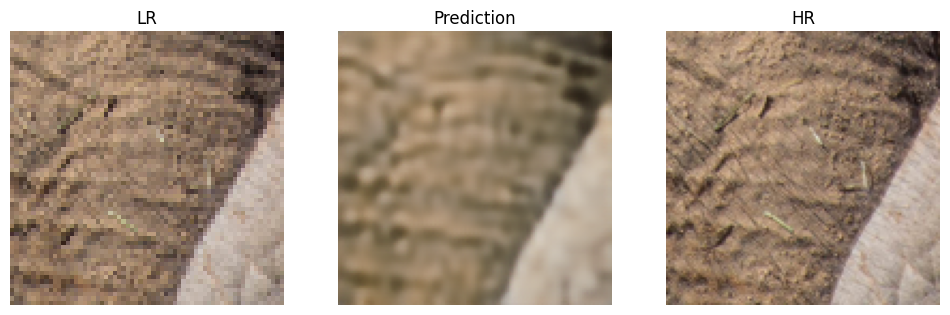

In [51]:
plt.figure(figsize = (12,4))
plt.subplot(1,3,1)
plt.title('LR')
plt.imshow(lr[0])
plt.axis('off')

plt.subplot(1,3,2)
plt.title('Prediction')
plt.imshow(pred[0])
plt.axis('off')

plt.subplot(1,3,3)
plt.title('HR')
plt.imshow(hr[0])
plt.axis('off')

plt.show()

In [53]:
#Konstrukcija enkodera
# 3 conv sloja, prvi i drugi uče i izvlače parametre dok treći smanjjue sliku za pola
inputs = Input(shape = input_shape,name= 'encoder_input')
x = inputs

for filters in layer_filters:
    x = Conv2D(filters = filters,kernel_size = kernel_size,strides = 1,activation = 'relu',padding = 'same')(x)
    x = Conv2D(filters = filters,kernel_size = kernel_size,strides = 1,activation = 'relu',padding = 'same')(x)
    x = Conv2D(filters = filters,kernel_size = kernel_size,strides = 1,activation = 'relu',padding = 'same')(x)
    x = Conv2D(filters = filters,kernel_size = kernel_size,strides = 2,activation = 'relu',padding = 'same')(x)


shape = K.int_shape(x)

encoder = Model(inputs,x,name = 'bigger_encoder')
encoder.summary()

Model: "bigger_encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_42 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_44 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_45 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_46 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_47 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_48 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_49 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_50 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 674,528 (2.57 MB)

 Trainable params: 674,528 (2.57 MB)

 Non-trainable params: 0 (0.00 B)

In [59]:
decoder_input = Input(shape=shape[1:])
x = decoder_input

for filters in layer_filters[::-1]:
    x = Conv2DTranspose(filters=filters, kernel_size=kernel_size, strides=2,activation='relu', padding='same')(x)
    x = Conv2D(filters=filters, kernel_size=kernel_size, strides=1,activation='relu', padding='same')(x)
    x = Conv2D(filters=filters, kernel_size=kernel_size, strides=1,activation='relu', padding='same')(x)

x = Conv2DTranspose(filters=32, kernel_size=kernel_size, strides=2,activation='relu', padding='same')(x)
x = Conv2D(filters=3, kernel_size=kernel_size, strides=1,padding='same')(x)

outputs = Activation('sigmoid', name='decoder_output')(x)

decoder = Model(inputs = decoder_input, outputs = outputs, name = 'bigger_decoder')

decoder.summary(line_length = 110)

Model: "bigger_decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                   ┃ Output Shape                        ┃             Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)                     │ (None, 8, 8, 128)                   │                   0 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ conv2d_transpose_28 (Conv2DTranspose)          │ (None, 16, 16, 128)                 │             147,584 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ conv2d_93 (Conv2D)                             │ (None, 16, 16, 128)                 │             147,584 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ conv2d_94 (Conv2D)                             │ (None, 16, 16, 128)                 │             147,584 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ conv2d_transpose_29 (Conv2DTranspose)          │ (None, 32, 32, 64)                  │              73,792 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ conv2d_95 (Conv2D)                             │ (None, 32, 32, 64)                  │              36,928 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ conv2d_96 (Conv2D)                             │ (None, 32, 32, 64)                  │              36,928 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ conv2d_transpose_30 (Conv2DTranspose)          │ (None, 64, 64, 32)                  │              18,464 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ conv2d_97 (Conv2D)                             │ (None, 64, 64, 32)                  │               9,248 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ conv2d_98 (Conv2D)                             │ (None, 64, 64, 32)                  │               9,248 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ conv2d_transpose_31 (Conv2DTranspose)          │ (None, 128, 128, 32)                │               9,248 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ conv2d_99 (Conv2D)                             │ (None, 128, 128, 3)                 │                 867 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ decoder_output (Activation)                    │ (None, 128, 128, 3)                 │                   0 │
└────────────────────────────────────────────────┴─────────────────────────────────────┴─────────────────────┘

 Total params: 637,475 (2.43 MB)

 Trainable params: 637,475 (2.43 MB)

 Non-trainable params: 0 (0.00 B)

In [61]:
#kreiranje glvnog autoencoder modela koji sadrži encoder i decoder
autoencoder = Model(inputs,decoder(encoder(inputs)),name = 'bigger_autoencoder')
autoencoder.summary()

Model: "bigger_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bigger_encoder (Functional)     │ (None, 8, 8, 128)      │       674,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bigger_decoder (Functional)     │ (None, 128, 128, 3)    │       821,987 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,496,515 (5.71 MB)

 Trainable params: 1,496,515 (5.71 MB)

 Non-trainable params: 0 (0.00 B)

In [62]:
#Kompajliranje i treniranje modela, čuvanje modela
autoencoder.compile(loss='MAE', metrics = [psnr_metrics],optimizer='adam')

In [63]:
callbacks3 = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath="../models/best_model_bigger.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

In [64]:
history = autoencoder.fit(
    ds_train,
    validation_data=ds_val,
    epochs=EPOCHS,
    verbose=1,
    callbacks = callbacks3
)

Epoch 1/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 19s 234ms/step - loss: 0.1990 - psnr_metrics: 13.3226 - val_loss: 0.1656 - val_psnr_metrics: 14.2423
Epoch 2/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 17s 259ms/step - loss: 0.1233 - psnr_metrics: 16.8312 - val_loss: 0.1042 - val_psnr_metrics: 18.3883
Epoch 3/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 17s 251ms/step - loss: 0.1033 - psnr_metrics: 18.4455 - val_loss: 0.0959 - val_psnr_metrics: 19.2675
Epoch 4/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 17s 252ms/step - loss: 0.0963 - psnr_metrics: 19.0480 - val_loss: 0.0938 - val_psnr_metrics: 19.3377
Epoch 5/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 17s 260ms/step - loss: 0.0946 - psnr_metrics: 19.3019 - val_loss: 0.0894 - val_psnr_metrics: 19.8881
Epoch 6/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 17s 259ms/step - loss: 0.0892 - psnr_metrics: 19.8158 - val_loss: 0.0902 - val_psnr_metrics: 19.7146
Epoch 7/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 17s 261ms/step - loss: 0.0850 - psnr_metrics: 20.1882 - val_loss: 0.0846 - val_psnr_metrics: 20.0371
Epoch 8/100
66/66 ━━

In [65]:
ds_test = make_sr_dataset(test_paths,HR_SIZE,SCALE,BATCH,False)
lr,hr = next(iter(ds_test))

In [66]:
pred = autoencoder.predict(lr)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step


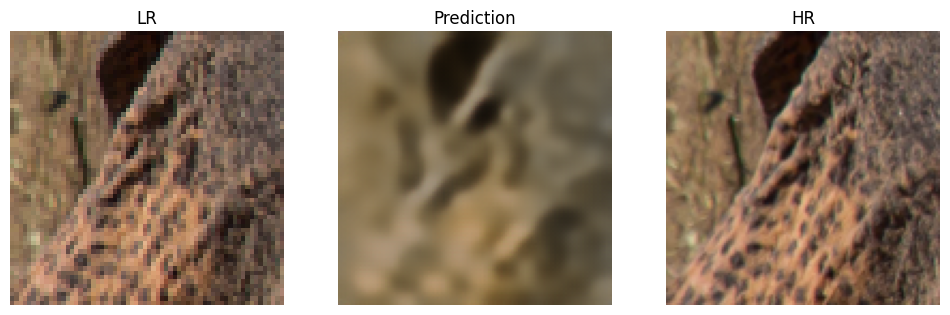

In [67]:
plt.figure(figsize = (12,4))
plt.subplot(1,3,1)
plt.title('LR')
plt.imshow(lr[0])
plt.axis('off')

plt.subplot(1,3,2)
plt.title('Prediction')
plt.imshow(pred[0])
plt.axis('off')

plt.subplot(1,3,3)
plt.title('HR')
plt.imshow(hr[0])
plt.axis('off')

plt.show()